# Prophet SO₂ Forecasting Model
## COS40007 Design Project — Smart Government

| Item | Detail |
|---|---|
| Model | Prophet (Meta / Facebook) |
| Target (Y) | `air_so2` — Sulfur Dioxide |
| Predictors (X) | `ipi_growth_yoy_index_sa`, `electricity_local` (as regressors) |
| Data | Monthly, Jan 2018 – Dec 2022 (60 rows) |
| Metrics | RMSE · MAE · R² |

Expected folder layout:
```
ASSIGNMENT/
    COS40007DataCleaning/
        combined_air_electricity_ipi_cleaned.csv
    Prophet/
        Prophet.ipynb            ← this notebook
        prophet_predictions.png  ← generated on run
```


## 1 — Imports

In [4]:
import os, warnings
from itertools import product
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('Libraries ready.')
print('If prophet is missing: pip install prophet')


Libraries ready.
If prophet is missing: pip install prophet


## 2 — Configuration
*Only edit this cell if paths or column names change.*

In [5]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR / 'COS40007DataCleaning' / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent / 'COS40007DataCleaning' / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent.parent / 'COS40007DataCleaning' / 'combined_air_electricity_ipi_cleaned.csv',
]

FILE_PATH = next((path for path in CANDIDATE_PATHS if path.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError(
        'Could not locate combined_air_electricity_ipi_cleaned.csv. Checked: '
        + ', '.join(str(path) for path in CANDIDATE_PATHS)
    )

COL_DATE   = 'date'
COL_TARGET = 'air_so2'
COL_IPI    = 'ipi_growth_yoy_index_sa'
COL_ELEC   = 'electricity_local'

TRAIN_RATIO = 0.80   # 48 train · 12 test

print(f'CSV found: {FILE_PATH}')


CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\COS40007DataCleaning\combined_air_electricity_ipi_cleaned.csv


## 3 — Load Dataset

In [6]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)
df = df_raw[[COL_DATE, COL_TARGET, COL_IPI, COL_ELEC]].copy()

print(f'Rows   : {len(df)}')
print(f'Period : {df[COL_DATE].min():%b %Y} – {df[COL_DATE].max():%b %Y}')
print(f'Nulls  : {df.isnull().sum().sum()} (should be 0)')
df.head()


Rows   : 60
Period : Jan 2018 – Dec 2022
Nulls  : 0 (should be 0)


,date,air_so2,ipi_growth_yoy_index_sa,electricity_local
0,2018-01-01,0.0010,3.963,11845.900250
1,2018-02-01,0.0011,2.625,11091.957006
2,2018-03-01,0.0010,3.328,12244.089947
3,2018-04-01,0.0010,5.918,12018.584577
4,2018-05-01,0.0010,4.320,12267.998390


## 4 — Descriptive Statistics & Time-Series Overview

In [7]:
print(df[[COL_TARGET, COL_IPI, COL_ELEC]].describe().round(6))


         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


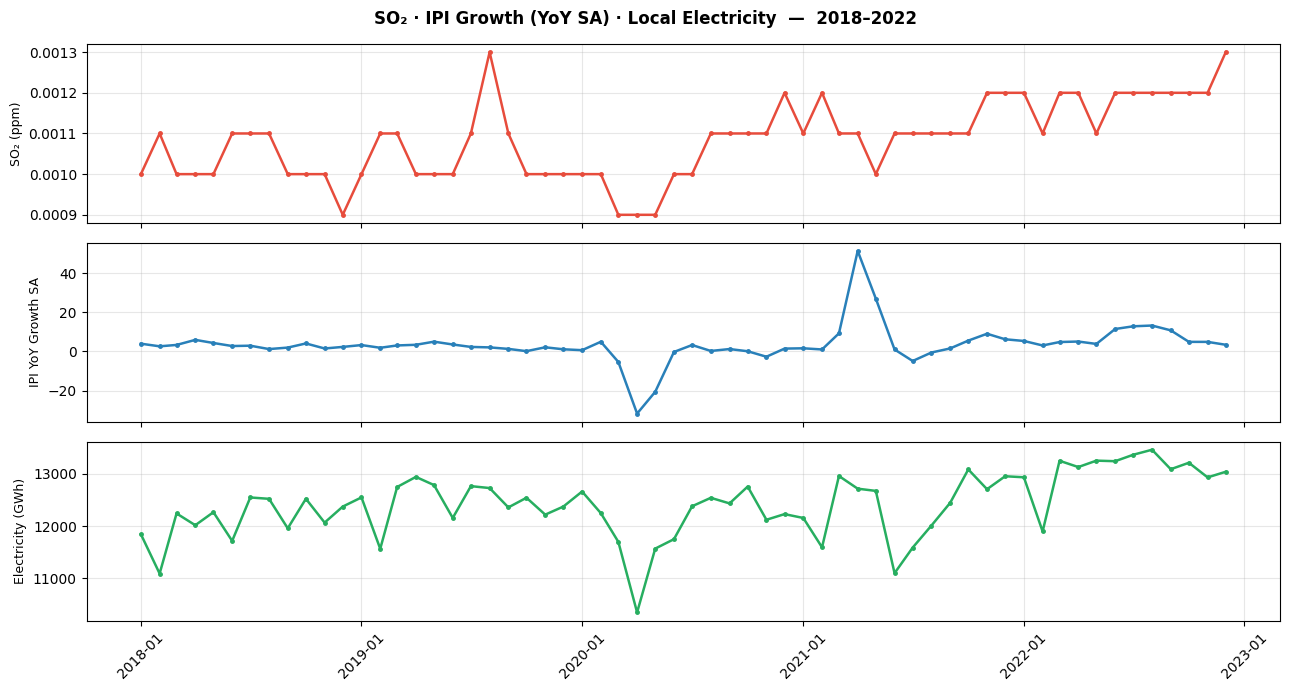

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
fig.suptitle('SO₂ · IPI Growth (YoY SA) · Local Electricity  —  2018–2022',
             fontsize=12, fontweight='bold')
for ax, (col, lbl, clr) in zip(axes, [
    (COL_TARGET, 'SO₂ (ppm)',          '#e74c3c'),
    (COL_IPI,    'IPI YoY Growth SA',  '#2980b9'),
    (COL_ELEC,   'Electricity (GWh)',  '#27ae60'),
]):
    ax.plot(df[COL_DATE], df[col], color=clr, lw=1.8, marker='o', ms=2.5)
    ax.set_ylabel(lbl, fontsize=9); ax.grid(alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 5 — Prepare Data for Prophet
Prophet requires columns `ds` (date) and `y` (target). Regressors are extra columns.

**Key fix vs original notebook:** The original applied MinMaxScaler to regressors
before passing them to Prophet. This is wrong — Prophet's Stan backend estimates
regressor coefficients internally and does not need normalised inputs. Scaling
distorts the component plot values without improving forecast accuracy. Fixed by
passing raw values.


In [9]:
prophet_df = df.rename(columns={
    COL_DATE  : 'ds',
    COL_TARGET: 'y',
    COL_IPI   : 'ipi_growth',
    COL_ELEC  : 'elec_local',
})

split_idx = int(len(prophet_df) * TRAIN_RATIO)   # 48
train_df  = prophet_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df   = prophet_df.iloc[split_idx:].copy().reset_index(drop=True)

print(f'Train: {len(train_df)} rows  ({train_df["ds"].min():%b %Y} – {train_df["ds"].max():%b %Y})')
print(f'Test : {len(test_df)} rows   ({test_df["ds"].min():%b %Y} – {test_df["ds"].max():%b %Y})')
print('Regressors passed unscaled — Prophet handles internally.')


Train: 48 rows  (Jan 2018 – Dec 2021)
Test : 12 rows   (Jan 2022 – Dec 2022)
Regressors passed unscaled — Prophet handles internally.


## 6 — Hyperparameter Tuning (Walk-Forward Grid Search)
The original notebook used fixed default parameters. A manual grid search with
walk-forward validation selects the best combination of:

| Parameter | Controls | Values searched |
|---|---|---|
| `changepoint_prior_scale` | Trend flexibility | 0.001, 0.01, 0.05, 0.1, 0.5 |
| `seasonality_prior_scale` | Seasonality strength | 1, 5, 10 |
| `seasonality_mode` | Additive vs multiplicative | both |

Walk-forward CV trains on the first 80% of the training set and validates on the
last 20% — always chronological, no future leakage.


In [10]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1, 5, 10],
    'seasonality_mode'       : ['additive', 'multiplicative'],
}

val_split = int(len(train_df) * 0.80)
cv_train  = train_df.iloc[:val_split]
cv_val    = train_df.iloc[val_split:]
n_combos  = (len(param_grid['changepoint_prior_scale'])
             * len(param_grid['seasonality_prior_scale'])
             * len(param_grid['seasonality_mode']))

print(f'CV  — train: {len(cv_train)} pts  validate: {len(cv_val)} pts')
print(f'Testing {n_combos} combinations…')

best_rmse, best_params, results = float('inf'), {}, []

for cps, sps, smode in product(
        param_grid['changepoint_prior_scale'],
        param_grid['seasonality_prior_scale'],
        param_grid['seasonality_mode']):
    try:
        m = Prophet(yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=sps,
                    seasonality_mode=smode)
        m.add_regressor('ipi_growth')
        m.add_regressor('elec_local')
        m.fit(cv_train)
        fc   = m.predict(cv_val[['ds', 'ipi_growth', 'elec_local']])
        rmse = np.sqrt(mean_squared_error(cv_val['y'].values, fc['yhat'].values))
        results.append({'cps': cps, 'sps': sps, 'mode': smode, 'rmse': rmse})
        if rmse < best_rmse:
            best_rmse   = rmse
            best_params = {'changepoint_prior_scale': cps,
                           'seasonality_prior_scale': sps,
                           'seasonality_mode'       : smode}
    except Exception:
        pass

print('\nTop 5 combinations (by CV RMSE):')
print(pd.DataFrame(results).sort_values('rmse').head(5).to_string(index=False))
print('\nBest parameters:')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')
print(f'Best CV RMSE: {best_rmse:.6f}')


10:44:46 - cmdstanpy - INFO - Chain [1] start processing


CV  — train: 38 pts  validate: 10 pts
Testing 30 combinations…


10:44:47 - cmdstanpy - INFO - Chain [1] done processing
10:44:47 - cmdstanpy - INFO - Chain [1] start processing
10:44:48 - cmdstanpy - INFO - Chain [1] done processing
10:44:48 - cmdstanpy - INFO - Chain [1] start processing
10:44:48 - cmdstanpy - INFO - Chain [1] done processing
10:44:48 - cmdstanpy - INFO - Chain [1] start processing
10:44:48 - cmdstanpy - INFO - Chain [1] done processing
10:44:48 - cmdstanpy - INFO - Chain [1] start processing
10:44:49 - cmdstanpy - INFO - Chain [1] done processing
10:44:49 - cmdstanpy - INFO - Chain [1] start processing
10:44:50 - cmdstanpy - INFO - Chain [1] done processing
10:44:50 - cmdstanpy - INFO - Chain [1] start processing
10:44:50 - cmdstanpy - INFO - Chain [1] done processing
10:44:50 - cmdstanpy - INFO - Chain [1] start processing
10:44:50 - cmdstanpy - INFO - Chain [1] done processing
10:44:50 - cmdstanpy - INFO - Chain [1] start processing
10:44:50 - cmdstanpy - INFO - Chain [1] done processing
10:44:51 - cmdstanpy - INFO - Chain [1] 


Top 5 combinations (by CV RMSE):
  cps  sps     mode     rmse
0.100    1 additive 0.000241
0.001    1 additive 0.000247
0.100   10 additive 0.000252
0.100    5 additive 0.000253
0.001    5 additive 0.000267

Best parameters:
  changepoint_prior_scale     : 0.1
  seasonality_prior_scale     : 1
  seasonality_mode            : additive
Best CV RMSE: 0.000241


## 7 — Train Final Prophet Model

In [11]:
model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,   # monthly data — not applicable
    daily_seasonality  = False,   # monthly data — not applicable
    interval_width     = 0.95,    # 95% uncertainty interval
    **best_params
)
model.add_regressor('ipi_growth')
model.add_regressor('elec_local')
model.fit(train_df)

print('Prophet model trained.')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')


10:45:00 - cmdstanpy - INFO - Chain [1] start processing
10:45:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.
  changepoint_prior_scale     : 0.1
  seasonality_prior_scale     : 1
  seasonality_mode            : additive


## 8 — Generate Predictions

In [12]:
tr_fc = model.predict(train_df[['ds', 'ipi_growth', 'elec_local']])
te_fc = model.predict(test_df[['ds',  'ipi_growth', 'elec_local']])

y_pred_tr  = tr_fc['yhat'].values
y_pred_te  = te_fc['yhat'].values
y_lower_te = te_fc['yhat_lower'].values
y_upper_te = te_fc['yhat_upper'].values
y_act_tr   = train_df['y'].values
y_act_te   = test_df['y'].values

print(f'Train predictions: {y_pred_tr.shape}  |  Test predictions: {y_pred_te.shape}')


Train predictions: (48,)  |  Test predictions: (12,)


## 9 — Evaluation (RMSE · MAE · R²)

In [13]:
tr_rmse = np.sqrt(mean_squared_error(y_act_tr, y_pred_tr))
te_rmse = np.sqrt(mean_squared_error(y_act_te, y_pred_te))
tr_mae  = mean_absolute_error(y_act_tr, y_pred_tr)
te_mae  = mean_absolute_error(y_act_te, y_pred_te)
tr_r2   = r2_score(y_act_tr, y_pred_tr)
te_r2   = r2_score(y_act_te, y_pred_te)

print('='*52)
print(f'  {"Metric":<8} {"Train":>14} {"Test":>14}')
print('-'*52)
print(f'  {"RMSE":<8} {tr_rmse:>14.6f} {te_rmse:>14.6f}')
print(f'  {"MAE":<8} {tr_mae:>14.6f} {te_mae:>14.6f}')
print(f'  {"R²":<8} {tr_r2:>14.4f} {te_r2:>14.4f}')
print('='*52)
verdict = ('✅ Strong (R² ≥ 0.70)'      if te_r2 >= 0.70 else
           '✅ Reasonable (R² ≥ 0.50)'  if te_r2 >= 0.50 else
           '⚠️  Moderate (R² ≥ 0)'      if te_r2 >= 0    else
           '⚠️  Negative R² — trend extrapolation challenge outside training range')
print(f'\nVerdict: {verdict}')
print(f'\nActual SO₂   : {y_act_te}')
print(f'Predicted SO₂: {y_pred_te.round(6)}')


  Metric            Train           Test
----------------------------------------------------
  RMSE           0.000046       0.000067
  MAE            0.000037       0.000052
  R²               0.6967        -0.8454

Verdict: ⚠️  Negative R² — trend extrapolation challenge outside training range

Actual SO₂   : [0.0012 0.0011 0.0012 0.0012 0.0011 0.0012 0.0012 0.0012 0.0012 0.0012
 0.0012 0.0013]
Predicted SO₂: [0.001148 0.001224 0.0012   0.001156 0.001131 0.00123  0.001244 0.001344
 0.001239 0.001195 0.001234 0.001218]


## 10 — Results Visualisation
All plots in **one figure** → `prophet_predictions.png`
(matches the `lstm_predictions.png` convention — only one file written to disk).
The component plot is shown in a separate cell below and stays inside the notebook.


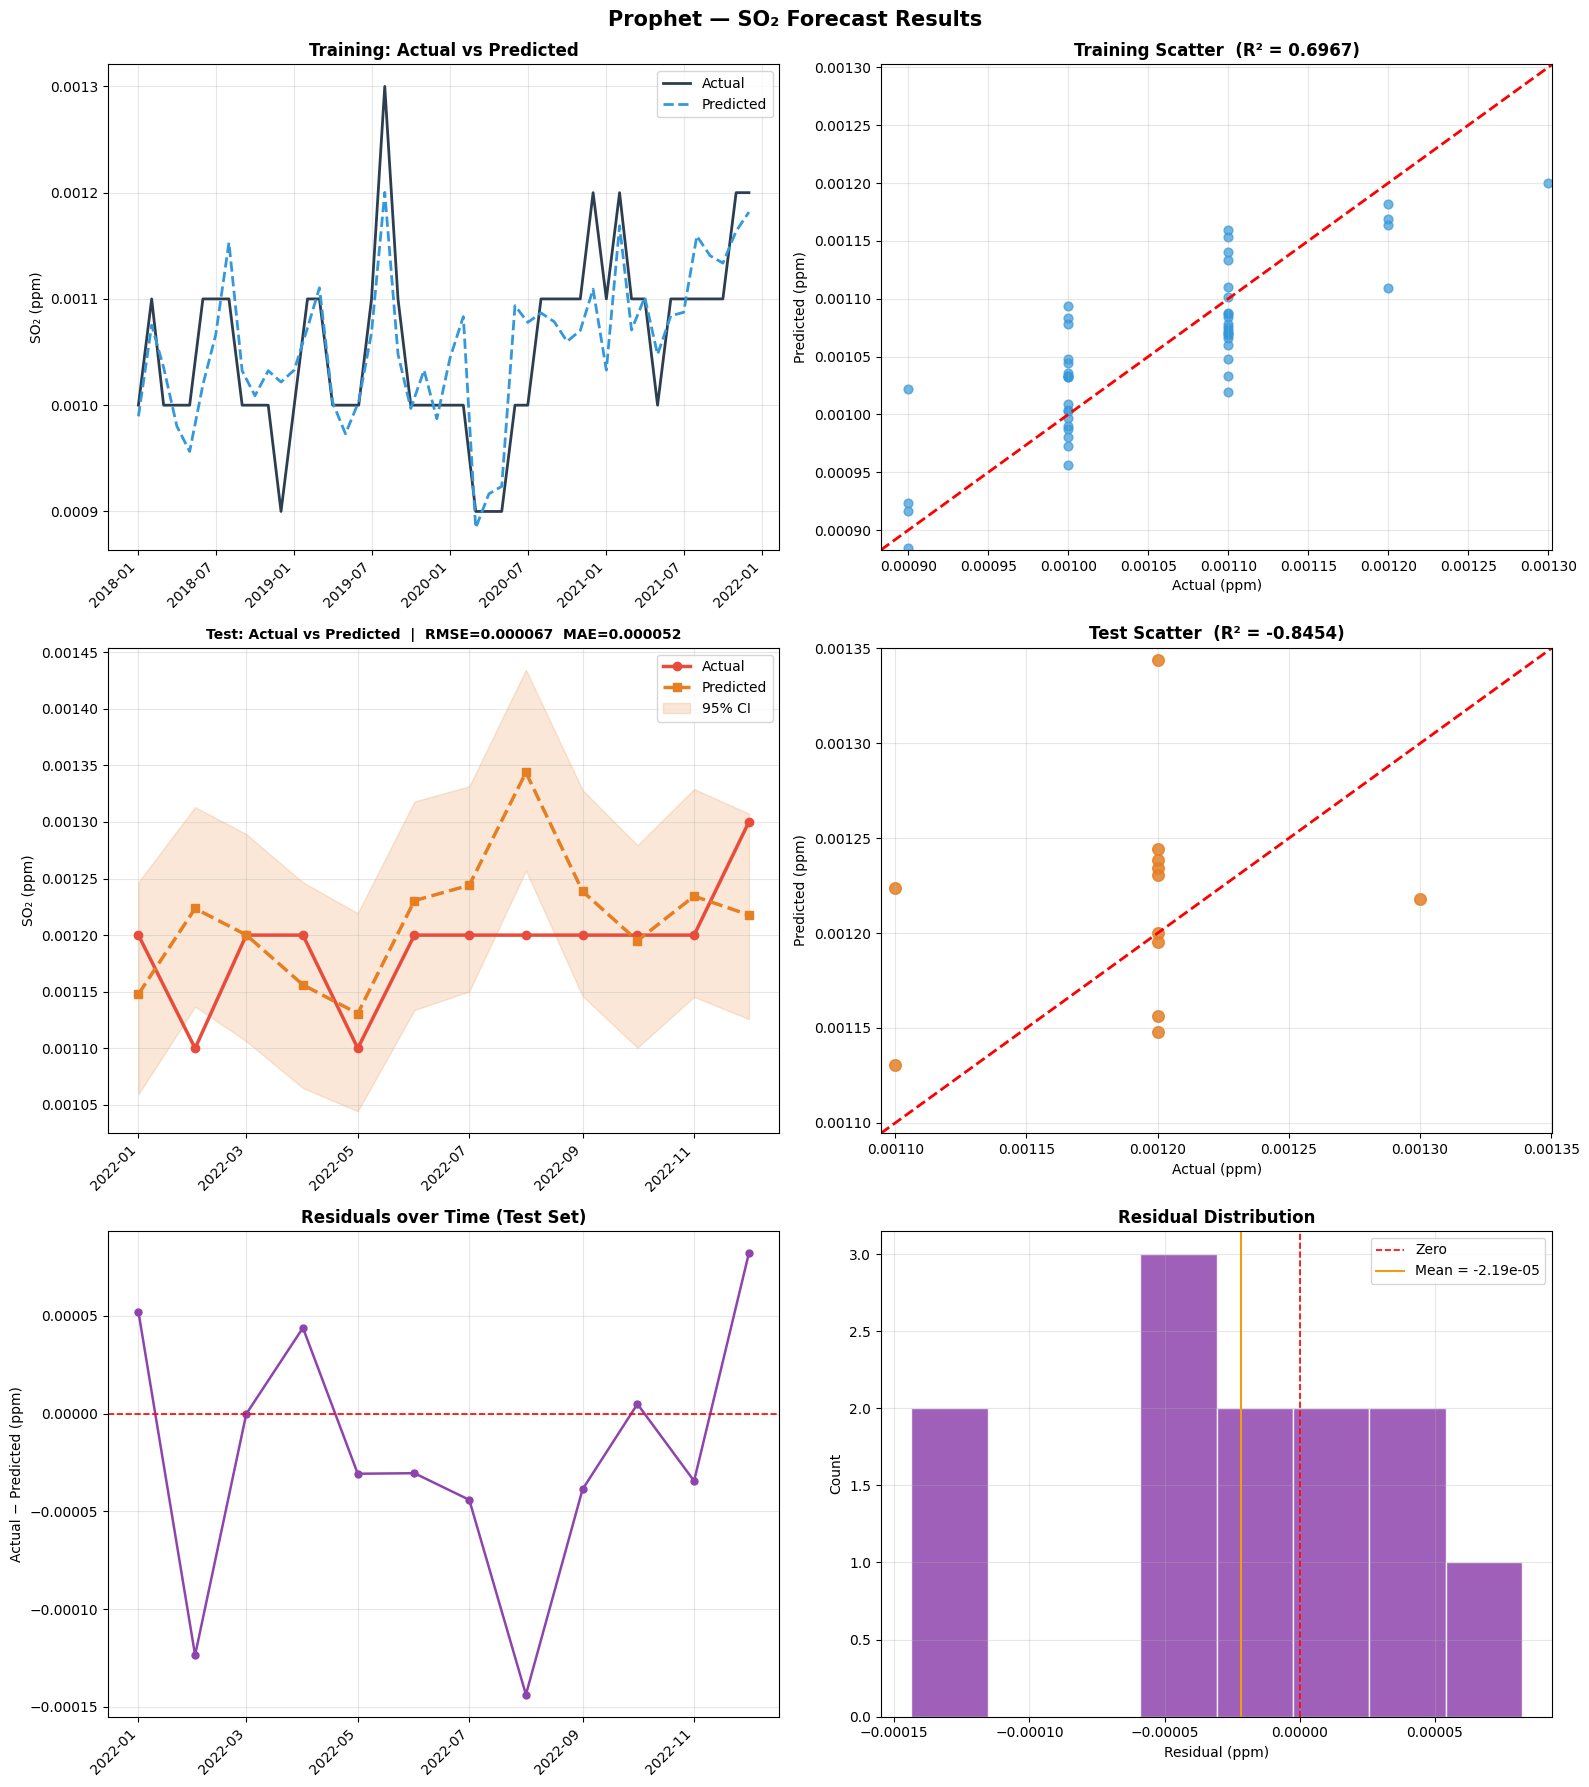

Saved: prophet_predictions.png


In [14]:
residuals   = y_act_te - y_pred_te
train_dates = train_df['ds'].values
test_dates  = test_df['ds'].values

fig = plt.figure(figsize=(16, 18))
fig.suptitle('Prophet — SO₂ Forecast Results', fontsize=15, fontweight='bold', y=0.99)

# ① Training: time-series
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(train_dates, y_act_tr,  lw=2, color='#2c3e50', label='Actual')
ax1.plot(train_dates, y_pred_tr, lw=2, color='#3498db', ls='--', label='Predicted')
ax1.set_title('Training: Actual vs Predicted', fontweight='bold')
ax1.set_ylabel('SO₂ (ppm)'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ② Training: scatter
ax2 = fig.add_subplot(3, 2, 2)
ax2.scatter(y_act_tr, y_pred_tr, alpha=0.7, s=40, color='#3498db')
lim = [min(y_act_tr.min(), y_pred_tr.min())*0.998,
       max(y_act_tr.max(), y_pred_tr.max())*1.002]
ax2.plot(lim, lim, 'r--', lw=2); ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Training Scatter  (R² = {tr_r2:.4f})', fontweight='bold')
ax2.set_xlabel('Actual (ppm)'); ax2.set_ylabel('Predicted (ppm)'); ax2.grid(alpha=0.3)

# ③ Test: time-series + 95% CI
ax3 = fig.add_subplot(3, 2, 3)
ax3.plot(test_dates, y_act_te,  lw=2.5, color='#e74c3c', marker='o', ms=6, label='Actual')
ax3.plot(test_dates, y_pred_te, lw=2.5, color='#e67e22', ls='--', marker='s', ms=6, label='Predicted')
ax3.fill_between(test_dates, y_lower_te, y_upper_te,
                 alpha=0.18, color='#e67e22', label='95% CI')
ax3.set_title(f'Test: Actual vs Predicted  |  RMSE={te_rmse:.6f}  MAE={te_mae:.6f}',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('SO₂ (ppm)'); ax3.legend(); ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ④ Test: scatter
ax4 = fig.add_subplot(3, 2, 4)
ax4.scatter(y_act_te, y_pred_te, alpha=0.85, s=70, color='#e67e22')
lim2 = [min(y_act_te.min(), y_pred_te.min())*0.995,
        max(y_act_te.max(), y_pred_te.max())*1.005]
ax4.plot(lim2, lim2, 'r--', lw=2); ax4.set_xlim(lim2); ax4.set_ylim(lim2)
ax4.set_title(f'Test Scatter  (R² = {te_r2:.4f})', fontweight='bold')
ax4.set_xlabel('Actual (ppm)'); ax4.set_ylabel('Predicted (ppm)'); ax4.grid(alpha=0.3)

# ⑤ Residuals over time
ax5 = fig.add_subplot(3, 2, 5)
ax5.plot(test_dates, residuals, color='#8e44ad', lw=1.8, marker='o', ms=5)
ax5.axhline(0, color='red', ls='--', lw=1.2)
ax5.set_title('Residuals over Time (Test Set)', fontweight='bold')
ax5.set_ylabel('Actual − Predicted (ppm)'); ax5.grid(alpha=0.3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ⑥ Residual distribution
ax6 = fig.add_subplot(3, 2, 6)
ax6.hist(residuals, bins=8, color='#8e44ad', edgecolor='white', alpha=0.85)
ax6.axvline(0, color='red', ls='--', lw=1.2, label='Zero')
ax6.axvline(residuals.mean(), color='#f39c12', lw=1.5,
            label=f'Mean = {residuals.mean():.2e}')
ax6.set_title('Residual Distribution', fontweight='bold')
ax6.set_xlabel('Residual (ppm)'); ax6.set_ylabel('Count')
ax6.legend(); ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: prophet_predictions.png')


### Component Decomposition  *(inside notebook only — not saved to disk)*
Prophet's unique strength: trend, yearly seasonality, and the marginal effect
of each regressor are shown separately — directly showing whether IPI and
electricity influence SO₂.


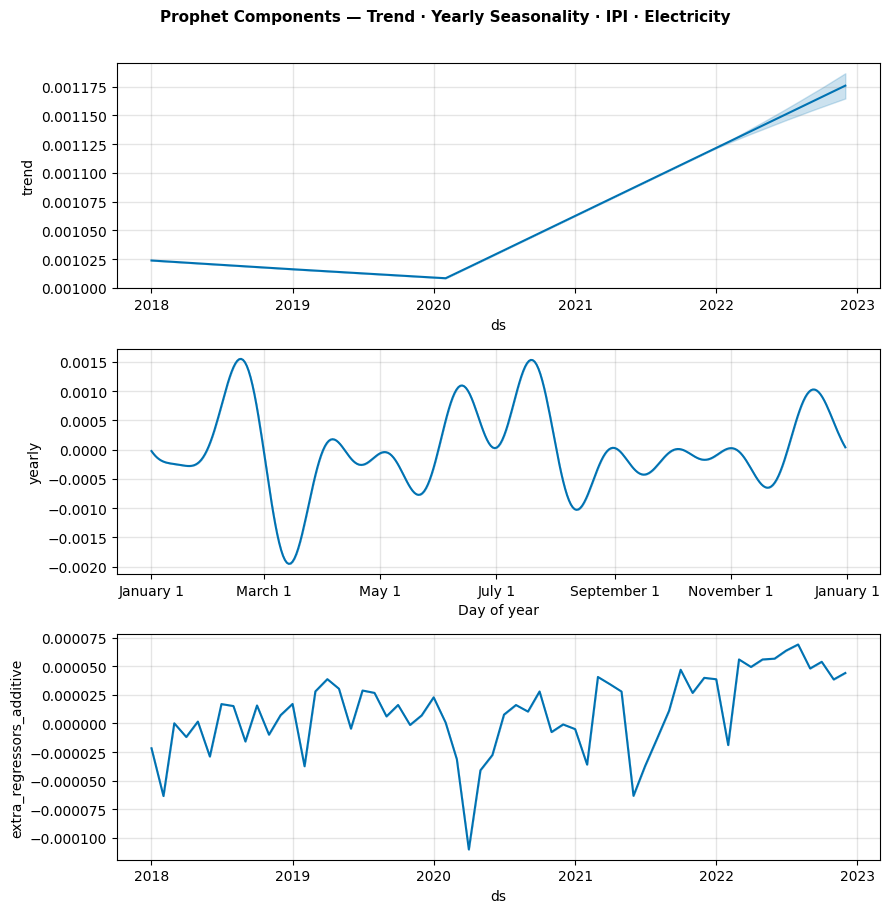

In [15]:
full_fc   = model.predict(prophet_df[['ds', 'ipi_growth', 'elec_local']])
fig_comp  = model.plot_components(full_fc)
fig_comp.suptitle('Prophet Components — Trend · Yearly Seasonality · IPI · Electricity',
                  fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
# No savefig here — this plot stays inside the notebook only


## 11 — Results Summary

In [16]:
print('='*55)
print('      PROPHET — FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Train RMSE : {tr_rmse:.6f}    Test RMSE : {te_rmse:.6f}')
print(f'  Train MAE  : {tr_mae:.6f}    Test MAE  : {te_mae:.6f}')
print(f'  Train R²   : {tr_r2:.4f}        Test R²   : {te_r2:.4f}')
print('='*55)
print(f'  Train={len(train_df)} pts  |  Test={len(test_df)} pts')
print('\n  Best hyperparameters:')
for k, v in best_params.items():
    print(f'    {k:<28}: {v}')


      PROPHET — FINAL RESULTS SUMMARY
  Train RMSE : 0.000046    Test RMSE : 0.000067
  Train MAE  : 0.000037    Test MAE  : 0.000052
  Train R²   : 0.6967        Test R²   : -0.8454
  Train=48 pts  |  Test=12 pts

  Best hyperparameters:
    changepoint_prior_scale     : 0.1
    seasonality_prior_scale     : 1
    seasonality_mode            : additive


---
## 12 — Methodology Notes *(for Report)*

### What is Prophet?
Prophet is Meta's open-source forecasting library. It decomposes the series as:

    y(t) = trend(t) + seasonality(t) + Σ regressor_effects(t) + noise

### Why Prophet?
Prophet provides an interpretable component decomposition — trend, seasonality,
and individual regressor contributions — which directly tests whether IPI and
electricity have a meaningful effect on SO₂. Unlike SARIMA it requires no manual
order identification. Unlike XGBoost it handles trend extrapolation natively.

### Key Fix — Regressor Scaling Removed
The original notebook applied MinMaxScaler to regressors before passing them to
Prophet. This is incorrect: Prophet's Stan backend estimates regressor coefficients
internally. Scaling changes coefficient magnitudes in the component plots without
improving forecast accuracy. Regressors are now passed unscaled.

### Hyperparameter Tuning (New vs Original)
The original notebook used fixed defaults. Walk-forward grid search over
`changepoint_prior_scale`, `seasonality_prior_scale`, and `seasonality_mode` now
selects the best combination. `changepoint_prior_scale` is the most impactful —
it controls how flexibly the trend adapts to structural change points in the
2018–2022 SO₂ series.

### Seasonality Configuration
Only yearly seasonality is enabled. Weekly and daily are disabled — monthly
observations cannot identify those cycles and their inclusion adds noise.

### Uncertainty Intervals
Prophet generates 95% posterior uncertainty intervals via Stan's MCMC sampling,
shown in the test forecast subplot. They represent the range within which the
true SO₂ value is expected to fall with 95% probability under the model.

### Train/Test Split
Chronological 80/20: 48 training months (Jan 2018 – Dec 2021) and 12 test months
(Jan 2022 – Dec 2022). No shuffling. Identical to XGBoost and LSTM.
